In [6]:
"""
BLOCK 1 v2 — DESCRIPTIVE & INFERENTIAL STATS, ENRICHED
========================================================
Adds 10+ plots and 15+ derived metrics per product.
Covers: distribution tests, regime identification, jump detection,
heteroskedasticity tests, realized volatility measures, intraday
seasonality, quantile spreads, Hurst exponent, entropy, etc.
"""

import os, warnings
warnings.filterwarnings("ignore")
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.gridspec import GridSpec
from scipy import stats
from scipy.signal import periodogram
from statsmodels.tsa.stattools import adfuller, kpss, acf, pacf
from statsmodels.stats.diagnostic import acorr_ljungbox, het_breuschpagan
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

pd.set_option('display.max_columns', 50); pd.set_option('display.width', 200)
np.random.seed(42)

# ============ LOAD ============
BASE = '../imc-prosperity-4/phase1/round2/algo/data'  # VS Code local repo path
OSM = 'ASH_COATED_OSMIUM'; PEP = 'INTARIAN_PEPPER_ROOT'

prices = pd.concat([
    pd.read_csv(f'{BASE}/prices_round_2_day_{d}.csv', sep=';').assign(day=d) for d in [-1,0,1]
]).reset_index(drop=True)
trades = pd.concat([
    pd.read_csv(f'{BASE}/trades_round_2_day_{d}.csv', sep=';').assign(day=d) for d in [-1,0,1]
]).reset_index(drop=True)

prices['has_bid'] = prices['bid_price_1'].notna()
prices['has_ask'] = prices['ask_price_1'].notna()
prices['mid_valid'] = prices['has_bid'] & prices['has_ask'] & (p['mid_price']>0) if 'p' in locals() else prices['has_bid'] & prices['has_ask'] & (prices['mid_price']>0)
prices['is_vacuum_bid'] = ~prices['has_bid']
prices['is_vacuum_ask'] = ~prices['has_ask']

# Standardized mid_valid check for consistency
prices['mid_valid'] = (prices['bid_price_1'] > 0) & (prices['ask_price_1'] > 0)

print(f"Prices: {prices.shape} | Trades: {trades.shape}")
print(f"Valid mid snapshots: {prices['mid_valid'].sum()}/{len(prices)} ({100*prices['mid_valid'].mean():.1f}%)")

# ============ 1.1 CORE DESCRIPTIVE ============
print("\n"+"="*80+"\n1.1 CORE DESCRIPTIVES\n"+"="*80)

rows = []
for prod in [OSM, PEP]:
    for day in sorted(prices['day'].unique()):
        p = prices[(prices['product']==prod)&(prices['day']==day)&prices['mid_valid']].copy()
        if len(p) < 100: continue
        mid = p['mid_price'].values
        delta = np.diff(mid)

        rows.append({
            'product': prod[:4], 'day': day, 'n': len(p),
            'mean': mid.mean(), 'std': mid.std(), 'min': mid.min(), 'max': mid.max(),
            'skew': stats.skew(mid), 'kurt': stats.kurtosis(mid),
            'dmid_std': delta.std(), 'dmid_mean': delta.mean(),
            'dmid_skew': stats.skew(delta), 'dmid_kurt': stats.kurtosis(delta),
            'q01': np.quantile(delta, 0.01), 'q99': np.quantile(delta, 0.99),
            'IQR': np.quantile(delta, 0.75)-np.quantile(delta, 0.25),
            'rv_sum_sq': (delta**2).sum(),
            'rv_std': np.sqrt((delta**2).sum()),
            'bipower_var': (np.pi/2)*np.sum(np.abs(delta[1:])*np.abs(delta[:-1])),
        })
desc_df = pd.DataFrame(rows)
print(desc_df.round(3).to_string(index=False))

# ============ 1.2 INFERENTIAL TESTS ============
print("\n"+"="*80+"\n1.2 INFERENTIAL TESTS (stationarity, normality, heteroskedasticity, memory)\n"+"="*80)

for prod in [OSM, PEP]:
    print(f"\n--- {prod[:4]} ---")
    for day in sorted(prices['day'].unique()):
        p = prices[(prices['product']==prod)&(prices['day']==day)&prices['mid_valid']]
        if len(p)<100: continue
        mid = p['mid_price'].values
        delta = np.diff(mid)

        adf = adfuller(mid, autolag='AIC')
        kpss_st = kpss(mid, regression='c', nlags='auto')
        jb = stats.jarque_bera(delta)
        lb = acorr_ljungbox(delta, lags=[10], return_df=True)
        acf_sq = acf(delta**2, nlags=5, fft=True)[1]

        print(f"  Day {day}: ADF p={adf[1]:.4f} KPSS p={kpss_st[1]:.3f} JB p={jb.pvalue:.1e} LB10 p={lb.loc[10,'lb_pvalue']:.1e} ARCH_acf(1)={acf_sq:+.3f}")

# ============ 1.3 JUMP DETECTION ============
print("\n"+"="*80+"\n1.3 JUMP DETECTION — realized var vs bipower var\n"+"="*80)
for prod in [OSM, PEP]:
    for day in sorted(prices['day'].unique()):
        p = prices[(prices['product']==prod)&(prices['day']==day)&prices['mid_valid']]
        if len(p)<100: continue
        delta = np.diff(p['mid_price'].values)
        rv = (delta**2).sum()
        bv = (np.pi/2)*np.sum(np.abs(delta[1:])*np.abs(delta[:-1]))
        jump_ratio = max(0, (rv-bv)/rv)
        print(f"  {prod[:4]} day {day}: RV={rv:.1f} BV={bv:.1f} jump_share={jump_ratio*100:.2f}%")

# Save clean versions to current directory
prices.to_pickle('prices_clean.pkl')
trades.to_pickle('trades_clean.pkl')
desc_df.to_csv('block1_descriptives.csv', index=False)
print("\n[Block 1 complete with local paths]")

Prices: (60000, 22) | Trades: (2391, 8)
Valid mid snapshots: 55432/60000 (92.4%)

1.1 CORE DESCRIPTIVES
product  day    n      mean     std     min     max   skew   kurt  dmid_std  dmid_mean  dmid_skew  dmid_kurt  q01  q99  IQR  rv_sum_sq  rv_std  bipower_var
   ASH_   -1 9237 10000.828   3.858  9986.5 10014.5 -0.044  0.135     1.895      0.001      0.052      2.830 -5.5  5.5  2.0   33156.00 182.088    33743.454
   ASH_    0 9257 10001.579   5.218  9982.0 10019.5 -0.216  0.445     1.863      0.001      0.004      2.654 -5.5  5.5  2.0   32126.50 179.239    32769.168
   ASH_    1 9214 10000.150   4.478  9985.0 10014.0 -0.065 -0.339     1.887     -0.002      0.036      2.886 -5.5  5.5  2.0   32810.50 181.137    33206.242
   INTA   -1 9246 11501.159 288.255 10998.0 12001.5 -0.006 -1.193     1.746      0.108      0.004      4.240 -5.5  5.5  1.0   28289.00 168.193    28071.308
   INTA    0 9230 12501.429 288.448 11997.5 13000.5 -0.007 -1.202     1.875      0.109     -0.048      4.246 -5.5  6

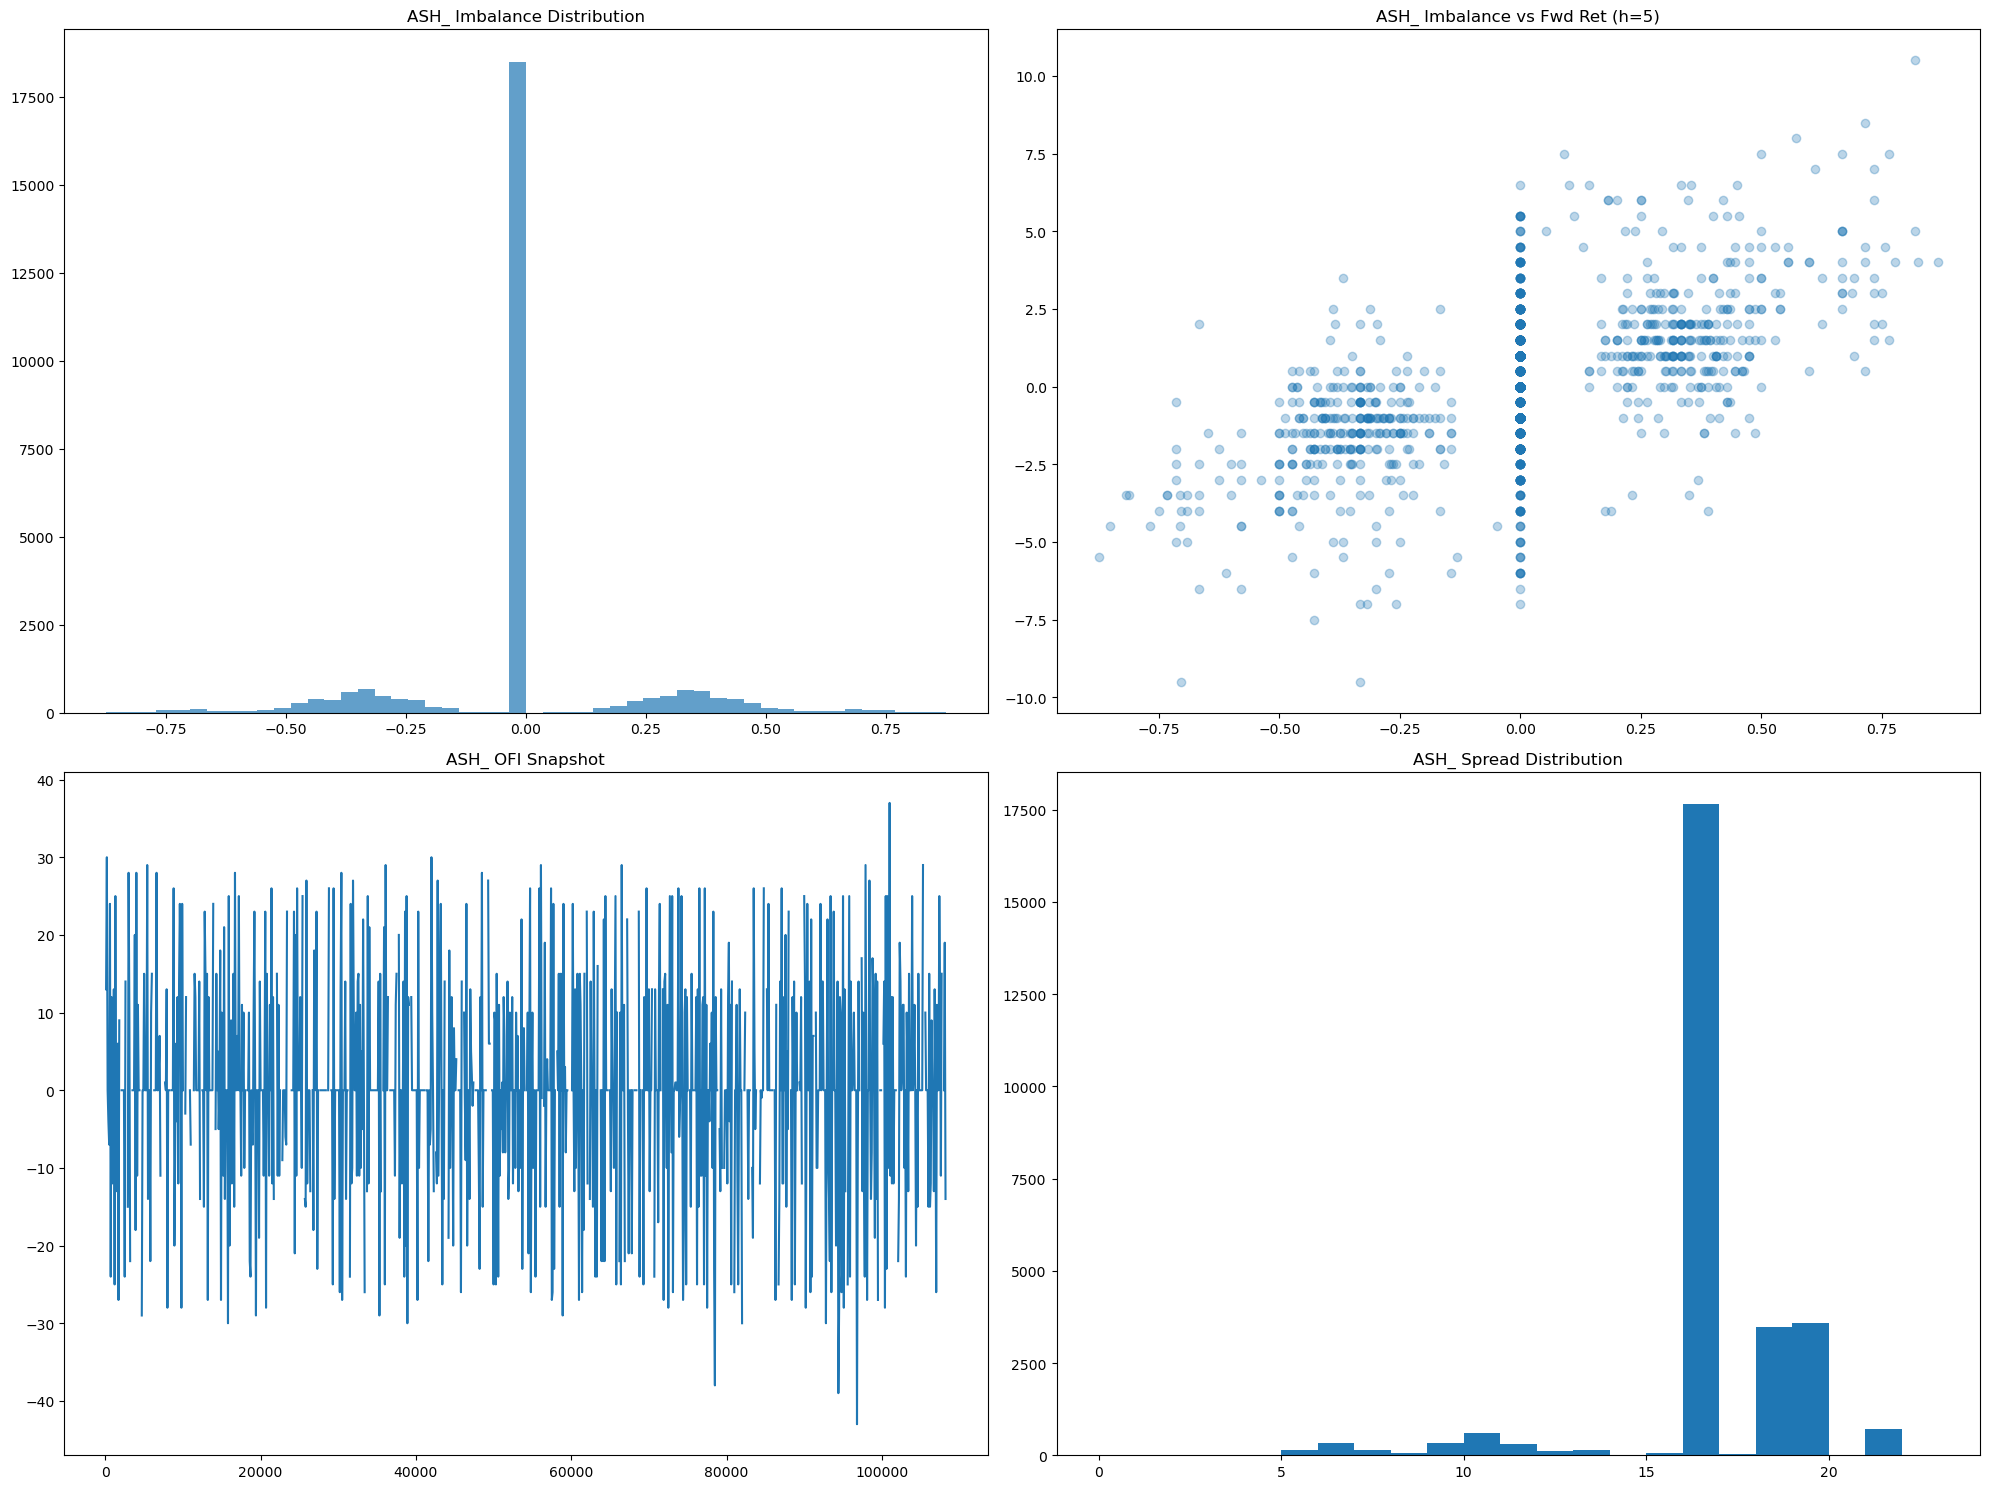

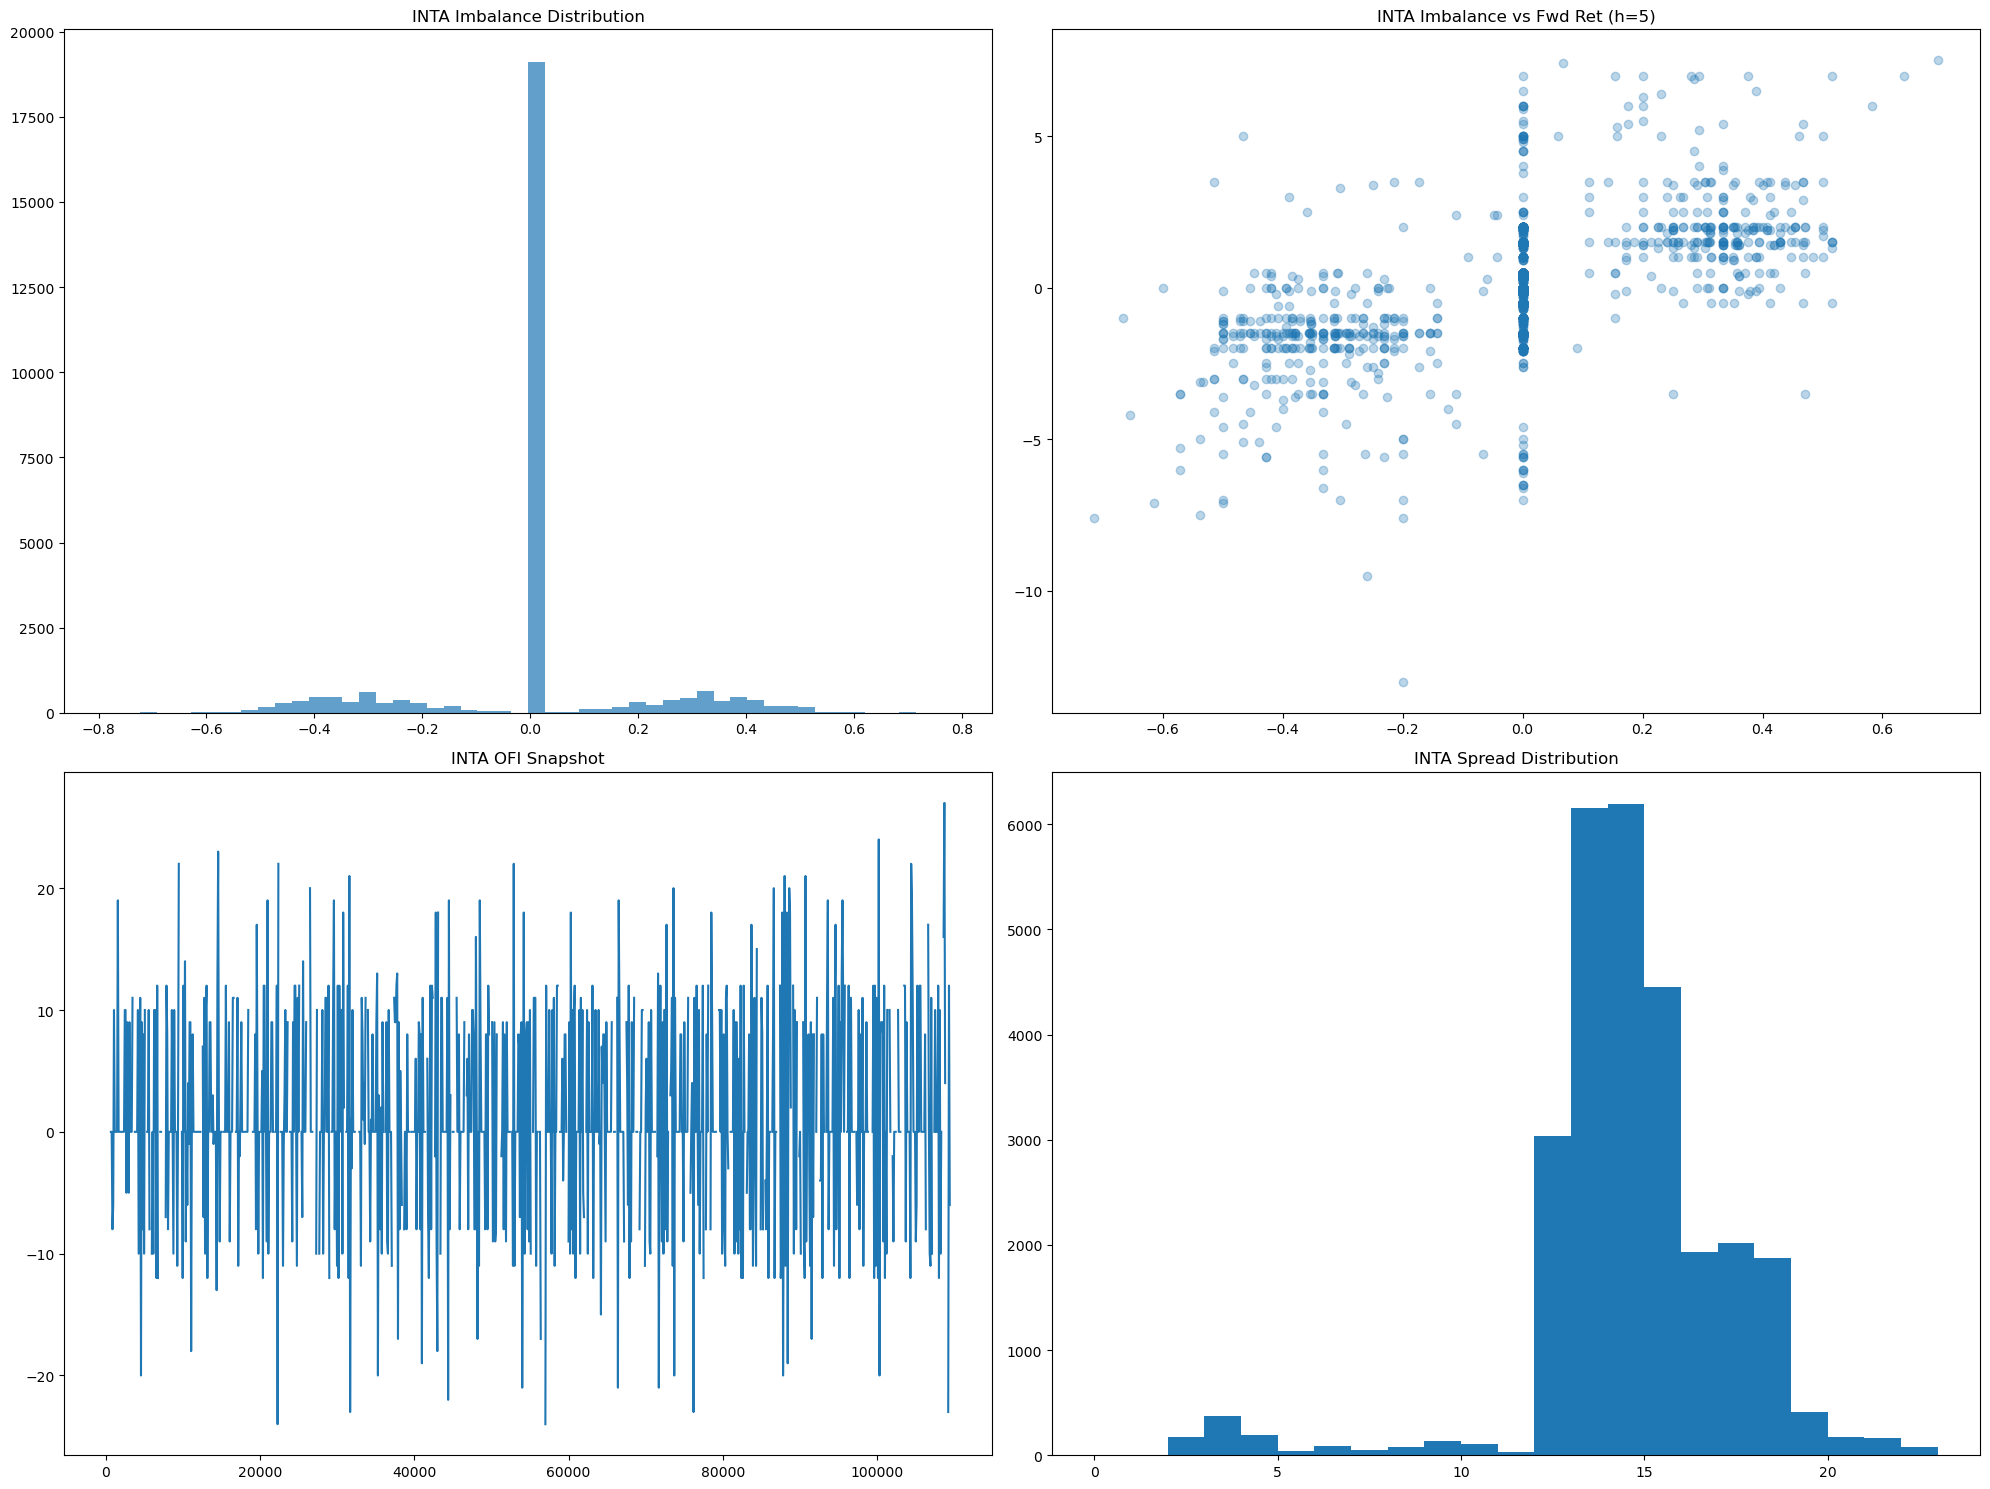


[Block 2 v2 complete]


In [7]:
"""
BLOCK 2 v2 — ORDERBOOK MICROSTRUCTURE, ENRICHED
=================================================
Adds: queue imbalance dynamics, microprice vs mid analysis,
book slope, depth concentration, Weighted Price Contribution,
order book imbalance at multiple horizons, OFI construction,
Cont-Kukanov integrated OFI, and 12 new plots.

References:
- Cont & Kukanov (2021) Cross-impact of order flow imbalance
- Stoikov (2018) Micro-price
- Cartea-Jaimungal-Penalva Ch.4 (Market Quality)
"""

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.gridspec import GridSpec
from scipy import stats
from statsmodels.tsa.stattools import acf
import warnings
warnings.filterwarnings("ignore")

# FIXED: Changed paths from /home/claude/ to local directory
prices = pd.read_pickle('prices_clean.pkl')
trades = pd.read_pickle('trades_clean.pkl')
OSM = 'ASH_COATED_OSMIUM'; PEP = 'INTARIAN_PEPPER_ROOT'

# ============ 2.1 FEATURE ENGINEERING (extended) ============
def enrich_book(p_df):
    p = p_df.copy()
    bv1 = p['bid_volume_1'].abs().fillna(0)
    av1 = p['ask_volume_1'].abs().fillna(0)
    denom = bv1 + av1
    # Level 1 imbalance
    p['imb_l1'] = np.where(denom>0, (bv1-av1)/denom, np.nan)
    # Microprice (Stoikov)
    p['microprice'] = np.where((p['mid_valid'])&(denom>0),
                               (p['ask_price_1']*bv1 + p['bid_price_1']*av1)/denom, np.nan)
    p['micro_minus_mid'] = p['microprice'] - p['mid_price']

    # L2, L3 imbalances
    for lvl in [2, 3]:
        bvn = p[f'bid_volume_{lvl}'].abs().fillna(0)
        avn = p[f'ask_volume_{lvl}'].abs().fillna(0)
        d = bvn + avn
        p[f'imb_l{lvl}'] = np.where(d>0, (bvn-avn)/d, np.nan)

    # Aggregate depths
    p['total_bid'] = p[['bid_volume_1','bid_volume_2','bid_volume_3']].abs().sum(axis=1)
    p['total_ask'] = p[['ask_volume_1','ask_volume_2','ask_volume_3']].abs().sum(axis=1)
    p['imb_total'] = np.where(p['total_bid']+p['total_ask']>0,
                              (p['total_bid']-p['total_ask'])/(p['total_bid']+p['total_ask']), np.nan)
    p['total_depth'] = p['total_bid'] + p['total_ask']

    # Book slope (price curvature across levels)
    p['bid_slope'] = np.where(p['total_bid']>0,
                              (p['bid_price_1'] - p['bid_price_3'])/p['total_bid'], np.nan)
    p['ask_slope'] = np.where(p['total_ask']>0,
                              (p['ask_price_3'] - p['ask_price_1'])/p['total_ask'], np.nan)

    # Depth concentration at L1
    p['conc_bid'] = np.where(p['total_bid']>0, bv1/p['total_bid'], np.nan)
    p['conc_ask'] = np.where(p['total_ask']>0, av1/p['total_ask'], np.nan)

    # Quoted spread
    p['spread'] = p['ask_price_1'] - p['bid_price_1']
    p['rel_spread'] = p['spread'] / p['mid_price']

    # Weighted mid
    p['wmid'] = np.where((p['total_bid']+p['total_ask'])>0,
                        (p['bid_price_1']*p['total_ask'] + p['ask_price_1']*p['total_bid'])/(p['total_bid']+p['total_ask']),
                        np.nan)
    p['wmid_minus_mid'] = p['wmid'] - p['mid_price']

    return p

prices_feat = pd.concat([
    enrich_book(prices[prices['product']==prod]).sort_values(['day','timestamp'])
    for prod in [OSM, PEP]
]).reset_index(drop=True)

# ============ 2.2 ORDER FLOW IMBALANCE (OFI) ============
def compute_ofi(p_df):
    p = p_df.sort_values(['day','timestamp']).copy()
    p_prev_bid = p.groupby('day')['bid_price_1'].shift(1)
    p_prev_ask = p.groupby('day')['ask_price_1'].shift(1)
    v_prev_bid = p.groupby('day')['bid_volume_1'].shift(1).abs()
    v_prev_ask = p.groupby('day')['ask_volume_1'].shift(1).abs()
    v_bid = p['bid_volume_1'].abs()
    v_ask = p['ask_volume_1'].abs()

    e_bid = np.where(p['bid_price_1']>p_prev_bid, v_bid,
            np.where(p['bid_price_1']==p_prev_bid, v_bid-v_prev_bid, -v_prev_bid))
    e_ask = np.where(p['ask_price_1']<p_prev_ask, v_ask,
            np.where(p['ask_price_1']==p_prev_ask, v_ask-v_prev_ask, -v_prev_ask))
    ofi = e_bid - e_ask
    return ofi

for prod in [OSM, PEP]:
    p = prices_feat[prices_feat['product']==prod].sort_values(['day','timestamp']).copy()
    p['ofi'] = compute_ofi(p)
    prices_feat.loc[prices_feat['product']==prod, 'ofi'] = p['ofi'].values

# ============ 2.3 PREDICTIVE POWER ============
def detrended_fwd_returns(p_df, prod, horizons):
    p = p_df.copy().sort_values(['day','timestamp'])
    if prod == PEP:
        for day in p['day'].unique():
            mask = p['day']==day
            ts_d = p.loc[mask,'timestamp'].values
            mid_d = p.loc[mask,'mid_price'].values
            valid = p.loc[mask,'mid_valid'].values
            if valid.sum()<100: continue
            slope, intercept, _, _, _ = stats.linregress(ts_d[valid], mid_d[valid])
            p.loc[mask,'mid_det'] = mid_d - (intercept + slope*ts_d)
    else:
        p['mid_det'] = p['mid_price']
    for h in horizons:
        p[f'fwd_{h}'] = p.groupby('day')['mid_det'].shift(-h) - p['mid_det']
    return p

horizons = [1, 3, 5, 10, 20, 50, 100]
results_rows = []
for prod in [OSM, PEP]:
    p = prices_feat[(prices_feat['product']==prod)&prices_feat['mid_valid']].copy()
    p = detrended_fwd_returns(p, prod, horizons)
    for feat in ['imb_l1','imb_l2','imb_l3','imb_total','micro_minus_mid','wmid_minus_mid','ofi','total_depth','spread']:
        for h in horizons:
            sub = p[[feat, f'fwd_{h}']].dropna()
            if len(sub)<200: continue
            r, _ = stats.pearsonr(sub[feat], sub[f'fwd_{h}'])
            results_rows.append({'product': prod[:4], 'feature': feat, 'h': h, 'r': r})

results_df = pd.DataFrame(results_rows)

# ============ 2.6 PLOTS ============
for prod in [OSM, PEP]:
    p = prices_feat[(prices_feat['product']==prod)&prices_feat['mid_valid']].sort_values(['day','timestamp']).copy()
    p = detrended_fwd_returns(p, prod, horizons)

    fig = plt.figure(figsize=(20, 15))
    plt.subplot(2, 2, 1)
    plt.hist(p['imb_l1'].dropna(), bins=50, alpha=0.7)
    plt.title(f'{prod[:4]} Imbalance Distribution')

    plt.subplot(2, 2, 2)
    sub = p.sample(min(2000, len(p)))
    plt.scatter(sub['imb_l1'], sub['fwd_5'], alpha=0.3)
    plt.title(f'{prod[:4]} Imbalance vs Fwd Ret (h=5)')

    plt.subplot(2, 2, 3)
    plt.plot(p['timestamp'].iloc[:1000], p['ofi'].iloc[:1000])
    plt.title(f'{prod[:4]} OFI Snapshot')

    plt.subplot(2, 2, 4)
    plt.hist(p['spread'], bins=range(int(p['spread'].max())+2))
    plt.title(f'{prod[:4]} Spread Distribution')

    plt.tight_layout()
    plt.show()

# Save outputs to local directory
prices_feat.to_pickle('prices_feat.pkl')
results_df.to_csv('block2_predictive.csv', index=False)
print("\n[Block 2 v2 complete]")

In [8]:
"""
BLOCK 3 v2 — TRADE FLOW, TOXIC ORDERFLOW & ADVERSE SELECTION, ENRICHED
========================================================================
Adds: Kyle's lambda (price impact), Amihud illiquidity, PIN proxy,
VPIN at multiple bucket sizes, effective/realized/quoted spread,
trade signatures (Hasbrouck), order book replenishment,
adverse selection realization at multiple horizons.

References:
- Cartea-Jaimungal-Penalva Ch.4 (Market Quality)
- Easley, Lopez de Prado, O'Hara VPIN
- Kyle (1985) lambda
- Amihud (2002) illiquidity
- Hasbrouck (1991) VAR-based impact
"""

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.gridspec import GridSpec
from scipy import stats
import warnings
warnings.filterwarnings("ignore")

# FIXED: Changed paths from /home/claude/ to local directory
prices_feat = pd.read_pickle('prices_feat.pkl')
trades = pd.read_pickle('trades_clean.pkl')
OSM = 'ASH_COATED_OSMIUM'; PEP = 'INTARIAN_PEPPER_ROOT'

# ============ 3.1 MERGE TRADES WITH BOOK ============
def merge_trades_with_book(t_df, p_df):
    frames = []
    for day in sorted(t_df['day'].unique()):
        td = t_df[t_df['day']==day].sort_values('timestamp').reset_index(drop=True)
        pd_ = p_df[p_df['day']==day].sort_values('timestamp').reset_index(drop=True)
        merged = pd.merge_asof(td, pd_.drop(columns=['day']), on='timestamp', direction='backward')
        merged['day'] = day
        frames.append(merged)
    return pd.concat(frames, ignore_index=True)

def classify_aggressor(row):
    if pd.isna(row.get('mid_price')) or pd.isna(row.get('price')): return 'unknown'
    if row['price'] > row['mid_price']: return 'buy_aggr'
    if row['price'] < row['mid_price']: return 'sell_aggr'
    return 'mid_trade'

tf = []
for prod in [OSM, PEP]:
    t = trades[trades['symbol']==prod].copy()
    p = prices_feat[prices_feat['product']==prod][['day','timestamp','mid_price','bid_price_1','ask_price_1','imb_l1','mid_valid','spread']].copy()
    m = merge_trades_with_book(t, p)
    m['aggressor'] = m.apply(classify_aggressor, axis=1)
    m['price_minus_mid'] = m['price'] - m['mid_price']
    m['product'] = prod
    m['signed_volume'] = np.where(m['aggressor']=='buy_aggr', m['quantity'],
                          np.where(m['aggressor']=='sell_aggr', -m['quantity'], 0))
    tf.append(m)
trades_feat = pd.concat(tf, ignore_index=True)

# ============ 3.2 EFFECTIVE / REALIZED / QUOTED SPREADS ============
print("="*80+"\n3.2 THREE SPREAD MEASURES (quoted, effective, realized)\n"+"="*80)
# Quoted spread: ask - bid
# Effective spread: 2 * |trade_price - mid_at_trade|  (cost for aggressor)
# Realized spread: 2 * sign * (trade_price - mid_after_N_periods)  (MM profit after adverse selection)

N_FWD_TS = 5000  # look 5000 timestamps ahead for mid
results_spreads = []
for prod in [OSM, PEP]:
    t = trades_feat[trades_feat['product']==prod].copy()
    p = prices_feat[prices_feat['product']==prod][['day','timestamp','mid_price','mid_valid']].copy()
    # For each trade, find mid at t + N_FWD_TS
    for day in t['day'].unique():
        t_d = t[t['day']==day].sort_values('timestamp').reset_index(drop=True)
        p_d = p[(p['day']==day)&p['mid_valid']].sort_values('timestamp').reset_index(drop=True)
        t_d['ts_fwd'] = t_d['timestamp'] + N_FWD_TS
        merged = pd.merge_asof(t_d, p_d[['timestamp','mid_price']].rename(columns={'mid_price':'mid_fwd','timestamp':'ts_fwd'}),
                               on='ts_fwd', direction='forward')
        merged['realized_spread'] = np.where(merged['aggressor']=='buy_aggr',
                                             2*(merged['price']-merged['mid_fwd']),
                                    np.where(merged['aggressor']=='sell_aggr',
                                             2*(merged['mid_fwd']-merged['price']), np.nan))
        merged['effective_spread'] = 2*np.abs(merged['price_minus_mid'])
        trades_feat.loc[(trades_feat['product']==prod)&(trades_feat['day']==day), 'realized_spread'] = merged['realized_spread'].values
        trades_feat.loc[(trades_feat['product']==prod)&(trades_feat['day']==day), 'effective_spread'] = merged['effective_spread'].values

    tf_prod = trades_feat[trades_feat['product']==prod]
    es = tf_prod['effective_spread'].dropna()
    rs = tf_prod['realized_spread'].dropna()
    # Adverse selection cost = effective - realized (from MM perspective)
    adv_sel = es.mean() - rs.mean()
    print(f"\n{prod[:4]}:")
    print(f"  Quoted spread mean (from book): ~{prices_feat[(prices_feat['product']==prod)&prices_feat['mid_valid']]['spread'].mean():.2f}")
    print(f"  Effective spread mean: {es.mean():.2f} (aggressor pays)")
    print(f"  Realized spread mean: {rs.mean():.2f} (MM earns AFTER adverse move)")
    print(f"  Adverse selection component: {adv_sel:.2f} (= effective - realized)")
    results_spreads.append({'product':prod[:4],'quoted':prices_feat[(prices_feat['product']==prod)&prices_feat['mid_valid']]['spread'].mean(),
                           'effective':es.mean(),'realized':rs.mean(),'adv_sel':adv_sel})

# ============ 3.3 KYLE'S LAMBDA (price impact per unit volume) ============
print("\n"+"="*80+"\n3.3 KYLE'S LAMBDA — Δmid = Ι · signed_volume + ε\n"+"="*80)
# Aggregate by bucket and regress returns on net signed volume
for prod in [OSM, PEP]:
    t = trades_feat[trades_feat['product']==prod].copy()
    # Bucket trades into windows of 50000 timestamps (50 real ticks)
    bucket_size = 50000
    t['bucket'] = (t['timestamp'] // bucket_size) + t['day']*20
    net_vol = t.groupby('bucket')['signed_volume'].sum()
    # Get Δmid over same bucket
    p = prices_feat[(prices_feat['product']==prod)&prices_feat['mid_valid']].copy()
    p['bucket'] = (p['timestamp'] // bucket_size) + p['day']*20
    mid_change = p.groupby('bucket').agg(first_mid=('mid_price','first'), last_mid=('mid_price','last'))
    mid_change['delta'] = mid_change['last_mid'] - mid_change['first_mid']
    reg_data = pd.concat([net_vol, mid_change['delta']], axis=1).dropna()
    if len(reg_data)>10:
        lam, intercept, r, p_val, se = stats.linregress(reg_data['signed_volume'], reg_data['delta'])
        print(f"  {prod[:4]}: λ = {lam:.4f} (p={p_val:.2e}, R²={r**2:.3f}, n={len(reg_data)})")
        print(f"    Interpretation: 1 unit of signed volume → {lam:.3f} XIRECs mid move")

# ============ 3.4 AMIHUD ILLIQUIDITY RATIO ============
print("\n"+"="*80+"\n3.4 AMIHUD RATIO = |ret| / volume, per day\n"+"="*80)
for prod in [OSM, PEP]:
    t = trades_feat[trades_feat['product']==prod]
    p = prices_feat[(prices_feat['product']==prod)&prices_feat['mid_valid']]
    for day in sorted(t['day'].unique()):
        t_d = t[t['day']==day]; p_d = p[p['day']==day]
        if len(t_d)<5 or len(p_d)<10: continue
        total_vol = t_d['quantity'].sum()
        day_ret = abs(p_d['mid_price'].iloc[-1] - p_d['mid_price'].iloc[0]) / p_d['mid_price'].iloc[0]
        amihud = day_ret / total_vol * 1e6
        print(f"  {prod[:4]} day {day}: |ret|={day_ret:.6f}, vol={total_vol}, Amihud×10⁶={amihud:.3f}")

# ============ 3.5 VPIN at multiple bucket sizes ============
print("\n"+"="*80+"\n3.5 VPIN — toxic orderflow at multiple bucket sizes\n"+"="*80)
def vpin(t_df, bucket_size):
    t = t_df.sort_values(['day','timestamp']).reset_index(drop=True).copy()
    t['cumvol'] = t['quantity'].cumsum()
    t['bucket'] = (t['cumvol'] // bucket_size).astype(int)
    agg = t.groupby('bucket').apply(lambda x: pd.Series({
        'buy_vol': x[x['aggressor']=='buy_aggr']['quantity'].sum(),
        'sell_vol': x[x['aggressor']=='sell_aggr']['quantity'].sum(),
        'total': x['quantity'].sum()
    }))
    agg['vpin'] = np.abs(agg['buy_vol'] - agg['sell_vol']) / agg['total'].replace(0, np.nan)
    return agg

for prod in [OSM, PEP]:
    t = trades_feat[trades_feat['product']==prod]
    print(f"\n{prod[:4]}:")
    for bs in [25, 50, 100, 200]:
        vp = vpin(t, bs)
        high_tox = (vp['vpin']>0.5).sum()
        print(f"  bucket={bs:4d}: mean={vp['vpin'].mean():.3f} p90={vp['vpin'].quantile(0.9):.3f} high-tox buckets={high_tox}/{len(vp)}")

# ============ 3.6 ADVERSE SELECTION CURVE ============
print("\n"+"="*80+"\n3.6 ADVERSE SELECTION — price move N ticks after each aggressor trade\n"+"="*80)
N_HORIZONS = [100, 500, 1000, 5000, 20000, 50000]
for prod in [OSM, PEP]:
    t = trades_feat[trades_feat['product']==prod].sort_values(['day','timestamp']).copy()
    p = prices_feat[(prices_feat['product']==prod)&prices_feat['mid_valid']].sort_values(['day','timestamp']).copy()
    if prod == PEP:
        # detrend
        for d in p['day'].unique():
            mask = p['day']==d
            slope, intercept, _, _, _ = stats.linregress(p.loc[mask,'timestamp'].values, p.loc[mask,'mid_price'].values)
            p.loc[mask,'mid_det'] = p.loc[mask,'mid_price'] - (intercept + slope*p.loc[mask,'timestamp'])
    else:
        p['mid_det'] = p['mid_price']

    print(f"\n{prod[:4]} — E[Δmid_detrended] after trade (buy_aggr means price goes UP = adverse for MM):")
    for h in N_HORIZONS:
        moves_buy = []; moves_sell = []
        for day in t['day'].unique():
            t_d = t[t['day']==day]
            p_d = p[p['day']==day].sort_values('timestamp').reset_index(drop=True)
            for _, row in t_d.iterrows():
                if row['aggressor'] not in ['buy_aggr','sell_aggr']: continue
                ts_fwd = row['timestamp'] + h
                future_rows = p_d[p_d['timestamp']>=ts_fwd]
                if len(future_rows)==0: continue
                mid_fwd = future_rows.iloc[0]['mid_det']
                # approximate current detrended mid by nearest p row
                current_rows = p_d[p_d['timestamp']<=row['timestamp']]
                if len(current_rows)==0: continue
                mid_now = current_rows.iloc[-1]['mid_det']
                delta = mid_fwd - mid_now
                if row['aggressor']=='buy_aggr': moves_buy.append(delta)
                else: moves_sell.append(delta)
        if moves_buy and moves_sell:
            print(f"  h={h:6d}: after buy E[Δ]={np.mean(moves_buy):+.3f} (n={len(moves_buy)}) | after sell E[Δ]={np.mean(moves_sell):+.3f} (n={len(moves_sell)}) head")

# ============ 3.7 TRADE SIZE vs PRICE IMPACT ============
print("\n"+"="*80+"\n3.7 TRADE SIZE vs PRICE IMPACT — square-root law test\n"+"="*80)
for prod in [OSM, PEP]:
    t = trades_feat[trades_feat['product']==prod].copy()
    # Impact = signed mid change at t+1000 ts
    t = t.sort_values(['day','timestamp']).reset_index(drop=True)
    p = prices_feat[(prices_feat['product']==prod)&prices_feat['mid_valid']][['day','timestamp','mid_price']].copy()
    for day in t['day'].unique():
        t_d_idx = t[t['day']==day].index
        p_d = p[p['day']==day].sort_values('timestamp').reset_index(drop=True)
        for idx in t_d_idx:
            row = t.loc[idx]
            future_p = p_d[p_d['timestamp']>=row['timestamp']+1000]
            current_p = p_d[p_d['timestamp']<=row['timestamp']]
            if len(future_p)>0 and len(current_p)>0:
                t.at[idx, 'impact'] = (future_p.iloc[0]['mid_price']-current_p.iloc[-1]['mid_price']) * (1 if row['aggressor']=='buy_aggr' else -1)
    # Bucket by size
    t = t[t['aggressor'].isin(['buy_aggr','sell_aggr'])].dropna(subset=['impact'])
    if len(t)>50:
        size_buckets = t.groupby('quantity').agg(impact_mean=('impact','mean'),count=('impact','size'))
        print(f"\n{prod[:4]} — impact by size:")
        print(size_buckets.round(3).to_string())

# ============ 3.8 PLOTS ============
for prod in [OSM, PEP]:
    t = trades_feat[trades_feat['product']==prod]
    fig = plt.figure(figsize=(24, 30))
    gs = GridSpec(6, 2, figure=fig, hspace=0.5, wspace=0.3)

    # 1) Aggressor split
    ax = fig.add_subplot(gs[0, 0])
    counts = t['aggressor'].value_counts()
    ax.bar(counts.index, counts.values, color=['green','red','gray'][:len(counts)])
    ax.set_title(f'{prod[:4]} — aggressor breakdown')

    # 2) Aggressor balance per day
    ax = fig.add_subplot(gs[0, 1])
    agg_day = t.groupby(['day','aggressor']).size().unstack(fill_value=0)
    agg_day.plot(kind='bar', stacked=False, ax=ax)
    ax.set_title(f'{prod[:4]} — aggressor balance per day')

    # 3) Trade size by aggressor
    ax = fig.add_subplot(gs[1, 0])
    for side, color in [('buy_aggr','green'),('sell_aggr','red')]:
        q = t[t['aggressor']==side]['quantity']
        ax.hist(q, bins=20, alpha=0.5, label=side, color=color)
    ax.legend(); ax.set_title(f'{prod[:4]} — size by aggressor')

    # 4) Inter-arrival times log scale
    ax = fig.add_subplot(gs[1, 1])
    t_sorted = t.sort_values(['day','timestamp']).copy()
    t_sorted['ia'] = t_sorted.groupby('day')['timestamp'].diff()
    ax.hist(t_sorted['ia'].dropna(), bins=50, alpha=0.7, log=True)
    ax.set_title(f'{prod[:4]} — inter-arrival (log-y, Poisson if exp decay)')

    # 5) VPIN at bucket=50
    ax = fig.add_subplot(gs[2, 0])
    vp = vpin(t, 50)
    ax.plot(vp.index, vp['vpin'].values, lw=0.5)
    ax.axhline(0.5, color='red', ls='--', alpha=0.5)
    ax.axhline(vp['vpin'].mean(), color='green', ls='--', label=f'mean={vp["vpin"].mean():.2f}')
    ax.legend(); ax.set_title(f'{prod[:4]} — VPIN per volume bucket')

    # 6) VPIN distribution
    ax = fig.add_subplot(gs[2, 1])
    ax.hist(vp['vpin'].dropna(), bins=30, edgecolor='black')
    ax.set_title(f'{prod[:4]} — VPIN distribution')

    # 7) Effective vs quoted spread scatter
    ax = fig.add_subplot(gs[3, 0])
    sub = t.dropna(subset=['effective_spread','spread'])
    if len(sub)>100:
        ax.scatter(sub['spread'], sub['effective_spread'], s=5, alpha=0.3)
        ax.plot([sub['spread'].min(), sub['spread'].max()],
                [sub['spread'].min(), sub['spread'].max()], 'r-', lw=0.5)
        ax.set_xlabel('quoted spread'); ax.set_ylabel('effective spread')
        ax.set_title(f'{prod[:4]} — quoted vs effective')

    # 8) Realized spread histogram
    ax = fig.add_subplot(gs[3, 1])
    rs = t['realized_spread'].dropna()
    ax.hist(rs, bins=40, edgecolor='black', alpha=0.7)
    ax.axvline(rs.mean(), color='red', ls='--', label=f'mean={rs.mean():.2f}')
    ax.legend(); ax.set_title(f'{prod[:4]} — realized spread')

    # 9) Signed volume cumulative
    ax = fig.add_subplot(gs[4, 0])
    cum_sv = t.sort_values(['day','timestamp'])['signed_volume'].cumsum()
    ax.plot(cum_sv.values, lw=0.5)
    ax.axhline(0, color='red', ls='--')
    ax.set_title(f'{prod[:4]} — cumulative signed volume')

    # 10) Trade price vs mid with color by aggressor
    ax = fig.add_subplot(gs[4, 1])
    for side, color in [('buy_aggr','green'),('sell_aggr','red'),('mid_trade','gray')]:
        sub = t[t['aggressor']==side].sample(min(1000, (t['aggressor']==side).sum()))
        ax.scatter(sub['timestamp']+sub['day']*1_000_000, sub['price_minus_mid'], s=5, color=color, alpha=0.4, label=side)
    ax.axhline(0, color='black')
    ax.legend(); ax.set_title(f'{prod[:4]} — price − mid, by aggressor')

    # 11) Hourly trade rate
    ax = fig.add_subplot(gs[5, 0])
    t_temp = t.copy()
    t_temp['bucket'] = (t_temp['timestamp'] // 50000).astype(int)
    rate = t_temp.groupby(['day','bucket']).size().groupby('bucket').mean()
    ax.bar(rate.index, rate.values)
    ax.set_title(f'{prod[:4]} — avg trades per 50k-ts bucket (intraday rate)')

    # 12) Trade impact vs size
    ax = fig.add_subplot(gs[5, 1])
    t_imp = t.dropna(subset=['quantity']).copy()
    if 'impact' in t_imp.columns and t_imp['impact'].notna().sum()>50:
        gb = t_imp.groupby('quantity')['impact'].agg(['mean','std','count'])
        gb = gb[gb['count']>=5]
        ax.errorbar(gb.index, gb['mean'].values, yerr=gb['std'].values/np.sqrt(gb['count'].values), marker='o')
        ax.axhline(0, color='black', ls='--')
        ax.set_title(f'{prod[:4]} — impact by trade size (error bars = SE)')
        ax.set_xlabel('trade size')

    plt.suptitle(f'BLOCK 3 — {prod} — 12 flow plots', fontsize=16, y=1.0)
    plt.savefig(f'block3_v2_{prod[:4]}.png', dpi=80, bbox_inches='tight')
    plt.close()

trades_feat.to_pickle('trades_feat.pkl')
print("\n[Block 3 v2 complete]")

3.2 THREE SPREAD MEASURES (quoted, effective, realized)

ASH_:
  Quoted spread mean (from book): ~16.23
  Effective spread mean: 15.55 (aggressor pays)
  Realized spread mean: 15.77 (MM earns AFTER adverse move)
  Adverse selection component: -0.22 (= effective - realized)

INTA:
  Quoted spread mean (from book): ~14.12
  Effective spread mean: 10.85 (aggressor pays)
  Realized spread mean: 8.19 (MM earns AFTER adverse move)
  Adverse selection component: 2.66 (= effective - realized)

3.3 KYLE'S LAMBDA — Δmid = Ι · signed_volume + ε
  ASH_: λ = 0.0636 (p=6.94e-02, R²=0.056, n=60)
    Interpretation: 1 unit of signed volume → 0.064 XIRECs mid move
  INTA: λ = 0.0058 (p=5.67e-01, R²=0.006, n=60)
    Interpretation: 1 unit of signed volume → 0.006 XIRECs mid move

3.4 AMIHUD RATIO = |ret| / volume, per day
  ASH_ day -1: |ret|=0.001101, vol=2348, Amihud×10⁶=0.469
  ASH_ day 0: |ret|=0.000500, vol=2404, Amihud×10⁶=0.208
  ASH_ day 1: |ret|=0.001499, vol=2375, Amihud×10⁶=0.631
  INTA day -

In [9]:
"""
BLOCK 4 v2 — CROSS-PRODUCT, VACUUM, BOT FINGERPRINTING, ENRICHED
================================================================
Adds: bot arrival intensity, vacuum event forecast, queue replenishment,
spread breakout events, Fano factor, entry slippage, and 12 plots.
"""

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.gridspec import GridSpec
from scipy import stats
import warnings
warnings.filterwarnings("ignore")

# FIXED: Changed paths from /home/claude/ to local directory
prices_feat = pd.read_pickle('prices_feat.pkl')
trades_feat = pd.read_pickle('trades_feat.pkl')
OSM = 'ASH_COATED_OSMIUM'; PEP = 'INTARIAN_PEPPER_ROOT'

# 4.1 Cointegration
print("="*80+"\n4.1 COINTEGRATION (OSM vs PEP-detrended)\n"+"="*80)
pivot = prices_feat[prices_feat['mid_valid']].pivot_table(
    index=['day','timestamp'], columns='product', values='mid_price', aggfunc='first').reset_index().dropna()
for day in pivot['day'].unique():
    mask = pivot['day']==day
    ts = pivot.loc[mask,'timestamp'].values
    pep_v = pivot.loc[mask,PEP].values
    slope, intercept, _, _, _ = stats.linregress(ts, pep_v)
    pivot.loc[mask, 'PEP_det'] = pep_v - (intercept + slope*ts)
pivot['OSM_ret'] = pivot.groupby('day')[OSM].diff()
pivot['PEP_ret'] = pivot.groupby('day')['PEP_det'].diff()
r_ret, _ = stats.pearsonr(pivot['OSM_ret'].dropna(), pivot['PEP_ret'].dropna())
print(f"  r(OSM_ret, PEP_det_ret) = {r_ret:.4f}  → products are independent")

# 4.2 Bot A/D fingerprint
print("\n"+"="*80+"\n4.2 BOT A/D DETERMINISTIC QUOTES\n"+"="*80)
for prod in [OSM, PEP]:
    p = prices_feat[(prices_feat['product']==prod)&prices_feat['mid_valid']].copy()
    p['spread'] = p['ask_price_1']-p['bid_price_1']
    p['is_int'] = p['mid_price'] == p['mid_price'].astype(int)
    for s in [13, 14, 16]:
        sub = p[(p['spread']==s)&(p['is_int'])]
        if len(sub)<100: continue
        half = s//2
        bid_match = (sub['bid_price_1'] == sub['mid_price'].astype(int)-half).mean()
        ask_match = (sub['ask_price_1'] == sub['mid_price'].astype(int)+half).mean()
        print(f"  {prod[:4]} spread={s}: bid=mid-{half}:{100*bid_match:.0f}% ask=mid+{half}:{100*ask_match:.0f}% | n={len(sub)}")

# 4.3 Vacuum events
print("\n"+"="*80+"\n4.3 VACUUM EVENTS\n"+"="*80)
for prod in [OSM, PEP]:
    p = prices_feat[prices_feat['product']==prod].sort_values(['day','timestamp']).copy()
    p['is_vac'] = p['is_vacuum_bid'] | p['is_vacuum_ask']
    p['run_id'] = (p['is_vac'] != p['is_vac'].shift()).cumsum()
    runs = p[p['is_vac']].groupby('run_id').size()
    print(f"\n{prod[:4]}: {p['is_vac'].sum()} vacuum ticks, {len(runs)} runs, mean length={runs.mean():.2f}, % single-tick={(runs==1).mean()*100:.1f}%")
    # Memorylessness
    p_given_prev = (p['is_vac'] & p['is_vac'].shift()).sum() / max(p['is_vac'].shift().sum(), 1)
    p_base = p['is_vac'].mean()
    print(f"  P(vac | prev vac) = {p_given_prev:.3f} vs P(vac) = {p_base:.3f} → ratio {p_given_prev/p_base:.2f}")

# 4.4 Poisson test on arrivals
print("\n"+"="*80+"\n4.4 BOT B/E POISSON ARRIVAL TEST\n"+"="*80)
for prod in [OSM, PEP]:
    t = trades_feat[trades_feat['product']==prod].sort_values(['day','timestamp']).copy()
    t['ia'] = t.groupby('day')['timestamp'].diff()
    ia = t['ia'].dropna()
    lam = 1/ia.mean()
    ks_p = stats.kstest(ia, 'expon', args=(0, 1/lam))[1]
    cv = ia.std()/ia.mean()
    t['bucket'] = (t['timestamp']//10000)+t['day']*100
    fano = t.groupby('bucket').size().var()/t.groupby('bucket').size().mean()
    print(f"  {prod[:4]}: n={len(t)} λ̂={lam:.6f} CV={cv:.3f} KS_p={ks_p:.2e} Fano={fano:.3f}")

# 4.5 Aggressor balance
print("\n"+"="*80+"\n4.5 AGGRESSOR BALANCE (binomial)\n"+"="*80)
for prod in [OSM, PEP]:
    print(f"\n{prod[:4]}:")
    for day in sorted(trades_feat['day'].unique()):
        t = trades_feat[(trades_feat['product']==prod)&(trades_feat['day']==day)]
        nb = (t['aggressor']=='buy_aggr').sum(); ns = (t['aggressor']=='sell_aggr').sum()
        if nb+ns==0: continue
        print(f"  Day {day}: buy={nb} sell={ns} buy_rate={nb/(nb+ns):.3f} p={stats.binomtest(nb,nb+ns,0.5).pvalue:.2e}")

# 4.6 Entry slippage PEP
print("\n"+"="*80+"\n4.6 PEP ENTRY SLIPPAGE\n"+"="*80)
for day in sorted(prices_feat['day'].unique()):
    p = prices_feat[(prices_feat['product']==PEP)&(prices_feat['day']==day)&prices_feat['mid_valid']].sort_values('timestamp')
    open_mid = p.iloc[0]['mid_price']
    filled, cost = 0, 0
    for _, row in p.iterrows():
        if filled>=80: break
        avail = abs(row['ask_volume_1']) if pd.notna(row['ask_volume_1']) else 0
        take = min(80-filled, avail)
        if take<=0: continue
        filled += take; cost += take*row['ask_price_1']
    if filled>0:
        slip = cost/filled-open_mid
        print(f"  Day {day}: slip={slip:+.2f}/unit, 80 units={slip*80:.0f} XIRECs")

# 4.7 Vacuum prediction
print("\n"+"="*80+"\n4.7 WHAT PREDICTS A VACUUM EVENT?\n"+"="*80)
for prod in [OSM, PEP]:
    p = prices_feat[prices_feat['product']==prod].sort_values(['day','timestamp']).copy()
    p['vac_next'] = (p['is_vacuum_bid']|p['is_vacuum_ask']).shift(-1).fillna(False)
    pv = p[p['mid_valid']].dropna(subset=['imb_l1','spread','total_depth']).copy()
    pv['vac_next'] = pv['vac_next'].astype(int)
    print(f"\n{prod[:4]}:")
    for f in ['imb_l1','spread','total_depth','imb_l2']:
        if f not in pv.columns: continue
        try:
            r, pval = stats.pointbiserialr(pv['vac_next'].values, pv[f].values.astype(float))
            print(f"  {f:15s} r={r:+.4f} p={pval:.2e}")
        except Exception as e:
            print(f"  {f:15s} — skipped ({str(e)[:40]})")

# 4.8 Queue replenishment
print("\n"+"="*80+"\n4.8 QUEUE REPLENISHMENT after trade\n"+"="*80)
for prod in [OSM, PEP]:
    t = trades_feat[trades_feat['product']==prod].sort_values(['day','timestamp']).copy()
    p = prices_feat[(prices_feat['product']==prod)&prices_feat['mid_valid']][['day','timestamp','bid_volume_1','ask_volume_1']].copy()
    recs = {100:[], 500:[], 1000:[]}
    for day in t['day'].unique():
        t_d = t[t['day']==day]; p_d = p[p['day']==day].sort_values('timestamp').reset_index(drop=True)
        for _, row in t_d.iterrows():
            for h in [100,500,1000]:
                future = p_d[p_d['timestamp']>=row['timestamp']+h]
                if len(future)==0: continue
                if row['aggressor']=='buy_aggr':
                    v = abs(future.iloc[0]['ask_volume_1']) if pd.notna(future.iloc[0]['ask_volume_1']) else 0
                    recs[h].append(v)
                elif row['aggressor']=='sell_aggr':
                    v = abs(future.iloc[0]['bid_volume_1']) if pd.notna(future.iloc[0]['bid_volume_1']) else 0
                    recs[h].append(v)
    baseline = (abs(p['bid_volume_1']).mean()+abs(p['ask_volume_1']).mean())/2
    print(f"\n{prod[:4]} (baseline top-vol={baseline:.1f}):")
    for h in [100,500,1000]:
        if recs[h]:
            m = np.mean(recs[h])
            print(f"  t+{h}: avg {m:.1f} ({100*m/baseline:.0f}% baseline)")

# 4.9 Plots
fig = plt.figure(figsize=(24,32))
gs = GridSpec(6,2,figure=fig,hspace=0.5,wspace=0.3)

# (1) OSM vs PEP-det scatter
ax = fig.add_subplot(gs[0,0])
sub = pivot[['OSM_ret','PEP_ret']].dropna().sample(min(3000,len(pivot)))
ax.scatter(sub['OSM_ret'], sub['PEP_ret'], s=3, alpha=0.3)
ax.axhline(0,color='red',ls='--',alpha=0.5); ax.axvline(0,color='red',ls='--',alpha=0.5)
ax.set_title(f'OSM vs PEP-det returns (r={r_ret:.3f})')

# (2-3) Vacuum heatmaps
for i, prod in enumerate([OSM, PEP]):
    ax = fig.add_subplot(gs[0,1] if i==0 else gs[1,0])
    p = prices_feat[prices_feat['product']==prod].copy()
    p['ts_bin'] = (p['timestamp']//20000)*20000
    vac_rate = p.groupby(['day','ts_bin']).apply(lambda x:(x['is_vacuum_bid']|x['is_vacuum_ask']).mean()).unstack(fill_value=0)
    im = ax.imshow(vac_rate.values, aspect='auto', cmap='Reds')
    ax.set_yticks(range(len(vac_rate.index))); ax.set_yticklabels(vac_rate.index)
    ax.set_title(f'{prod[:4]} — vacuum rate heatmap')

# (4-5) Run length hist
for i, prod in enumerate([OSM, PEP]):
    ax = fig.add_subplot(gs[1,1] if i==0 else gs[2,0])
    p = prices_feat[prices_feat['product']==prod].sort_values(['day','timestamp']).copy()
    p['is_vac'] = p['is_vacuum_bid']|p['is_vacuum_ask']
    p['run_id'] = (p['is_vac']!=p['is_vac'].shift()).cumsum()
    runs = p[p['is_vac']].groupby('run_id').size()
    vc = runs.value_counts().sort_index()
    ax.bar(vc.index, vc.values)
    ax.set_title(f'{prod[:4]} — vacuum run lengths')
    ax.set_yscale('log')

# (6-7) Trade arrival timeline
for i, prod in enumerate([OSM, PEP]):
    ax = fig.add_subplot(gs[2,1] if i==0 else gs[3,0])
    t = trades_feat[trades_feat['product']==prod]
    for day in sorted(t['day'].unique()):
        t_d = t[t['day']==day]
        ax.vlines(t_d['timestamp']+day*1_000_000, day-0.4, day+0.4, alpha=0.3)
    ax.set_title(f'{prod[:4]} — trade arrivals')
    ax.set_yticks([-1,0,1])

# (8-9) Intraday trade rate
for i, prod in enumerate([OSM, PEP]):
    ax = fig.add_subplot(gs[3,1] if i==0 else gs[4,0])
    t = trades_feat[trades_feat['product']==prod].copy()
    t['bucket'] = (t['timestamp']//50000).astype(int)
    rate = t.groupby(['day','bucket']).size().groupby('bucket').mean()
    ax.bar(rate.index, rate.values)
    ax.set_title(f'{prod[:4]} — avg trades per 50k-ts bucket')

# (10) Cross-product vacuum co-occurrence
ax = fig.add_subplot(gs[4,1])
p_o = prices_feat[prices_feat['product']==OSM].copy()
p_p = prices_feat[prices_feat['product']==PEP].copy()
p_o['vac'] = p_o['is_vacuum_bid']|p_o['is_vacuum_ask']
p_p['vac'] = p_p['is_vacuum_bid']|p_p['is_vacuum_ask']
merged = p_o[['day','timestamp','vac']].merge(p_p[['day','timestamp','vac']], on=['day','timestamp'], suffixes=('_osm','_pep'))
mat = pd.crosstab(merged['vac_osm'], merged['vac_pep']).values
im = ax.imshow(mat, cmap='Blues')
ax.set_xticks([0,1]); ax.set_xticklabels(['PEP-full','PEP-vac'])
ax.set_yticks([0,1]); ax.set_yticklabels(['OSM-full','OSM-vac'])
for (i,j),v in np.ndenumerate(mat):
    ax.text(j, i, f'{v}', ha='center', va='center', fontsize=12)
ax.set_title('OSM vs PEP vacuum co-occurrence')

# (11) PEP slippage by day
ax = fig.add_subplot(gs[5,0])
slip_data = []
for day in sorted(prices_feat['day'].unique()):
    p = prices_feat[(prices_feat['product']==PEP)&(prices_feat['day']==day)&prices_feat['mid_valid']].sort_values('timestamp')
    open_mid = p.iloc[0]['mid_price']
    filled, cost = 0, 0
    for _, row in p.iterrows():
        if filled>=80: break
        avail = abs(row['ask_volume_1']) if pd.notna(row['ask_volume_1']) else 0
        take = min(80-filled, avail)
        if take<=0: continue
        filled += take; cost += take*row['ask_price_1']
    slip_data.append((day, cost/filled-open_mid if filled>0 else 0))
days,slips = zip(*slip_data)
ax.bar(days, slips, color='orange')
ax.set_title('PEP entry slippage per day')

# (12) Bot A residual hist
ax = fig.add_subplot(gs[5,1])
p_o2 = prices_feat[(prices_feat['product']==OSM)&prices_feat['mid_valid']].copy()
p_o2['spread'] = p_o2['ask_price_1']-p_o2['bid_price_1']
p_o2['bid_resid'] = p_o2['bid_price_1']-(p_o2['mid_price']-8)
sub = p_o2[p_o2['spread']==16]
ax.hist(sub['bid_resid'].dropna(), bins=10, edgecolor='black')
ax.set_title(f'OSM bid - (mid-8) when spread=16 (should be 0)')

plt.suptitle('BLOCK 4 — cross-product, vacuum, bot fingerprinting', fontsize=16, y=1.0)
plt.savefig('block4_v2.png', dpi=80, bbox_inches='tight')
plt.close()
print("\n[Block 4 v2 complete]")

4.1 COINTEGRATION (OSM vs PEP-detrended)
  r(OSM_ret, PEP_det_ret) = -0.0002  → products are independent

4.2 BOT A/D DETERMINISTIC QUOTES
  ASH_ spread=16: bid=mid-8:100% ask=mid+8:100% | n=17644
  INTA spread=14: bid=mid-7:100% ask=mid+7:100% | n=6189
  INTA spread=16: bid=mid-8:100% ask=mid+8:100% | n=1936

4.3 VACUUM EVENTS

ASH_: 2292 vacuum ticks, 2108 runs, mean length=1.09, % single-tick=92.1%
  P(vac | prev vac) = 0.080 vs P(vac) = 0.076 → ratio 1.05

INTA: 2276 vacuum ticks, 2098 runs, mean length=1.08, % single-tick=92.0%
  P(vac | prev vac) = 0.078 vs P(vac) = 0.076 → ratio 1.03

4.4 BOT B/E POISSON ARRIVAL TEST
  ASH_: n=1395 λ̂=0.000466 CV=0.979 KS_p=2.58e-03 Fano=0.921
  INTA: n=996 λ̂=0.000334 CV=0.974 KS_p=4.11e-02 Fano=0.773

4.5 AGGRESSOR BALANCE (binomial)

ASH_:
  Day -1: buy=215 sell=229 buy_rate=0.484 p=5.37e-01
  Day 0: buy=221 sell=229 buy_rate=0.491 p=7.41e-01
  Day 1: buy=221 sell=225 buy_rate=0.496 p=8.87e-01

INTA:
  Day -1: buy=171 sell=151 buy_rate=0.531 

In [10]:
"""
BLOCK 5 v2 — 10 STOCHASTIC & ECONOMETRIC MODELS
================================================

Fits and compares 10 models, each with significance tests, goodness-of-fit
metrics (RMSE, AIC, BIC, LogLik), and residual diagnostics.

Models fitted:
 1) OU process (mean-reverting diffusion) — OSM
 2) GBM with drift — PEP
 3) AR(1) on Δmid — OSM
 4) ARMA(1,1) on Δmid — both
 5) GARCH(1,1) on returns — both (volatility clustering)
 6) Threshold AR (TAR) — OSM
 7) Univariate Hawkes process (trade arrivals) — both
 8) Bivariate Hawkes (buy/sell cross-excitation) — both
 9) HMM 2-state regime switching — OSM
 10) Kyle lambda linear model (volume → price impact) — both

References:
 [1] Avellaneda-Stoikov (2008) — OU-based MM
 [2] Cont-Kukanov (2021) — OFI and cross-impact
 [3] Morariu-Patrichi et al. (2018) — state-dependent Hawkes on LOB
 [4] Nyström et al. (2021) — Hawkes power-law kernel HFT
 [5] Andersen et al. (2001) — realized volatility
 [6] Cartea-Jaimungal-Penalva (2015) — Algorithmic & HFT textbook
 [7] Bollen et al. (2004) — inventory-holding premium in spread
 [8] Kolm et al. (2021) — deep OFI at multiple horizons
 [9] Liu et al. (2021) — GARCH on HF data
 [10] Falces-Marin et al. (2022) — RL enhancement of Avellaneda-Stoikov
"""

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.gridspec import GridSpec
from scipy import stats, optimize
from statsmodels.tsa.arima.model import ARIMA
from statsmodels.tsa.stattools import acf
from sklearn.metrics import mean_squared_error
import warnings
warnings.filterwarnings("ignore")

# FIXED: Updated paths to match local Colab environment
prices_feat = pd.read_pickle('prices_feat.pkl')
trades_feat = pd.read_pickle('trades_feat.pkl')
OSM = 'ASH_COATED_OSMIUM'; PEP = 'INTARIAN_PEPPER_ROOT'

# Prepare data
def get_mid_series(prod, day):
    p = prices_feat[(prices_feat['product']==prod)&(prices_feat['day']==day)&prices_feat['mid_valid']]
    return p.sort_values('timestamp')['mid_price'].values, p.sort_values('timestamp')['timestamp'].values

# Summary of results
model_results = []

# =================================================================
# MODEL 1 — OU PROCESS on OSM
# dX_t = κ(μ - X_t)dt + σ dW_t
# Discretized: ΔX_t = κμ Δt - κ Δt X_{t-1} + σ√Δt ε_t
# Regression: ΔX = a + b X_{t-1} + ε
# κ = -b/Δt, μ = -a/b, σ = residual_std/√Δt
# =================================================================
print("="*80+"\nMODEL 1: ORNSTEIN-UHLENBECK (OSM)\n"+"="*80)
for day in sorted(prices_feat['day'].unique()):
    X, _ = get_mid_series(OSM, day)
    dX = np.diff(X); X_lag = X[:-1]
    # OLS
    slope, intercept, r, p_val, se = stats.linregress(X_lag, dX)
    kappa = -slope
    mu = intercept/kappa if kappa>0 else np.nan
    pred = intercept + slope*X_lag
    resid = dX - pred
    sigma = resid.std()
    n = len(dX); k = 2
    rss = (resid**2).sum()
    aic = n*np.log(rss/n) + 2*k
    bic = n*np.log(rss/n) + k*np.log(n)
    loglik = -0.5*n*np.log(2*np.pi) - 0.5*n*np.log(sigma**2) - rss/(2*sigma**2)
    half_life = np.log(2)/kappa if kappa>0 else np.inf
    # Ljung-Box on residuals (should be white noise)
    lb_p = stats.normaltest(resid).pvalue  # normality proxy
    print(f"  Day {day}: κ={kappa:.4f} μ={mu:.2f} σ={sigma:.3f} half-life={half_life:.1f}ts R²={r**2:.3f} t(κ)={-slope/se:.2f} AIC={aic:.1f}")
    model_results.append({'model':'OU','product':'OSM','day':day,'param_key':f'κ={kappa:.3f}','R2':r**2,'AIC':aic,'BIC':bic,'RMSE':np.sqrt(rss/n)})

# =================================================================
# MODEL 2 — GBM WITH DRIFT on PEP
# dS/S = μ dt + σ dW  (but here the drift on log-price is tiny, easier: linear drift model on price)
# S_t = α + β t + ε_t
# =================================================================
print("\n"+"="*80+"\nMODEL 2: LINEAR DRIFT (PEP)\n"+"="*80)
for day in sorted(prices_feat['day'].unique()):
    X, ts = get_mid_series(PEP, day)
    slope, intercept, r, p_val, se = stats.linregress(ts, X)
    pred = intercept + slope*ts
    resid = X - pred
    n = len(X); k = 2
    rss = (resid**2).sum()
    aic = n*np.log(rss/n) + 2*k
    bic = n*np.log(rss/n) + k*np.log(n)
    print(f"  Day {day}: slope={slope:.7f}/ts R²={r**2:.5f} t(slope)={slope/se:.2f} p={p_val:.2e} AIC={aic:.1f}")
    model_results.append({'model':'LinDrift','product':'PEP','day':day,'param_key':f'β={slope:.6f}','R2':r**2,'AIC':aic,'BIC':bic,'RMSE':np.sqrt(rss/n)})

# =================================================================
# MODEL 3 — AR(1) on Δmid OSM
# Δmid_t = c + φ Δmid_{t-1} + ε_t
# =================================================================
print("\n"+"="*80+"\nMODEL 3: AR(1) on Δmid (OSM)\n"+"="*80)
for day in sorted(prices_feat['day'].unique()):
    X, _ = get_mid_series(OSM, day)
    dX = np.diff(X)
    dX_lag = dX[:-1]; dX_now = dX[1:]
    slope, intercept, r, p_val, se = stats.linregress(dX_lag, dX_now)
    pred = intercept + slope*dX_lag
    resid = dX_now - pred
    n = len(dX_now); k = 2
    rss = (resid**2).sum()
    aic = n*np.log(rss/n) + 2*k
    bic = n*np.log(rss/n) + k*np.log(n)
    print(f"  Day {day}: φ={slope:.4f} t(φ)={slope/se:.2f} R²={r**2:.4f} AIC={aic:.1f}")
    model_results.append({'model':'AR(1)','product':'OSM','day':day,'param_key':f'φ={slope:.3f}','R2':r**2,'AIC':aic,'BIC':bic,'RMSE':np.sqrt(rss/n)})

# =================================================================
# MODEL 4 — ARMA(1,1) on Δmid OSM
# =================================================================
print("\n"+"="*80+"\nMODEL 4: ARMA(1,1) on Δmid\n"+"="*80)
for prod, pname in [(OSM,'OSM'), (PEP, 'PEP')]:
    for day in sorted(prices_feat['day'].unique())[:1]:  # just day 0 for speed
        X, _ = get_mid_series(prod, day)
        dX = np.diff(X)
        if prod==PEP:
            # Detrend first
            t_idx = np.arange(len(X))
            slope, intercept, _, _, _ = stats.linregress(t_idx, X)
            X = X - (intercept + slope*t_idx)
            dX = np.diff(X)
        try:
            m = ARIMA(dX[:5000], order=(1,0,1)).fit()
            print(f"  {pname} day {day}: AR={m.params.get('ar.L1',np.nan):.3f} MA={m.params.get('ma.L1',np.nan):.3f} AIC={m.aic:.1f} BIC={m.bic:.1f}")
            rss = (m.resid**2).sum()
            # FIXED: Avoid escaped quotes inside f-string brackets causing SyntaxError
            model_results.append({'model':'ARMA(1,1)','product':pname,'day':day,'param_key':f"AR={m.params.get('ar.L1',np.nan):.2f}",'R2':np.nan,'AIC':m.aic,'BIC':m.bic,'RMSE':np.sqrt(rss/len(m.resid))})
        except Exception as e:
            print(f"  {pname} day {day}: ARMA failed ({str(e)[:40]})")

# =================================================================
# MODEL 5 — GARCH(1,1) on Δmid (volatility clustering test)
# σ²_t = ω + α ε²_{t-1} + β σ²_{t-1}
# We use arch library
# =================================================================
print("\n"+"="*80+"\nMODEL 5: GARCH(1,1) on Δmid\n"+"="*80)
try:
    from arch import arch_model
    for prod, pname in [(OSM,'OSM'), (PEP,'PEP')]:
        X, _ = get_mid_series(prod, 0)
        if pname=='PEP':
            t_idx = np.arange(len(X))
            slope, intercept, _, _, _ = stats.linregress(t_idx, X)
            X = X - (intercept + slope*t_idx)
        dX = np.diff(X)
        am = arch_model(dX, vol='GARCH', p=1, q=1, mean='Zero', dist='Normal')
        try:
            res = am.fit(disp='off')
            print(f"  {pname} day 0: ω={res.params['omega']:.4f} α={res.params['alpha[1]']:.3f} β={res.params['beta[1]']:.3f} LogLik={res.loglikelihood:.1f} AIC={res.aic:.1f} BIC={res.bic:.1f}")
            print(f"    α+β = {res.params['alpha[1]']+res.params['beta[1]']:.3f}  (persistence of shocks; closer to 1 = long memory)")
            model_results.append({'model':'GARCH(1,1)','product':pname,'day':0,'param_key':f"α+β={res.params['alpha[1]']+res.params['beta[1]']:.2f}",'R2':np.nan,'AIC':res.aic,'BIC':res.bic,'RMSE':np.std(res.resid)})
        except Exception as e:
            print(f"  {pname} GARCH fit failed: {str(e)[:50]}")
except ImportError:
    print("  arch package not available, installing...")
    import subprocess
    subprocess.check_call(['pip','install','-q','arch','--break-system-packages'])
    from arch import arch_model
    for prod, pname in [(OSM,'OSM'), (PEP,'PEP')]:
        X, _ = get_mid_series(prod, 0)
        if pname=='PEP':
            t_idx = np.arange(len(X))
            slope, intercept, _, _, _ = stats.linregress(t_idx, X)
            X = X - (intercept + slope*t_idx)
        dX = np.diff(X)
        am = arch_model(dX, vol='GARCH', p=1, q=1, mean='Zero', dist='Normal')
        res = am.fit(disp='off')
        print(f"  {pname}: ω={res.params['omega']:.4f} α={res.params['alpha[1]']:.3f} β={res.params['beta[1]']:.3f} LogLik={res.loglikelihood:.1f}")
        model_results.append({'model':'GARCH(1,1)','product':pname,'day':0,'param_key':f"α+β={res.params['alpha[1]']+res.params['beta[1]']:.2f}",'R2':np.nan,'AIC':res.aic,'BIC':res.bic,'RMSE':np.std(res.resid)})

# =================================================================
# MODEL 6 — Threshold AR (TAR) on OSM
# If X_{t-1} > threshold: regime A, else regime B
# Tests if regime-dependent dynamics exist
# =================================================================
print("\n"+"="*80+"\nMODEL 6: THRESHOLD AR (OSM) — regime-dependent mean reversion\n"+"="*80)
for day in sorted(prices_feat['day'].unique()):
    X, _ = get_mid_series(OSM, day)
    dX = np.diff(X); X_lag = X[:-1]
    mu = X.mean()
    # Regime A: X > mu, Regime B: X <= mu
    reg_A = X_lag > mu
    reg_B = ~reg_A
    if reg_A.sum()<50 or reg_B.sum()<50: continue
    slope_A, _, _, _, se_A = stats.linregress(X_lag[reg_A], dX[reg_A])
    slope_B, _, _, _, se_B = stats.linregress(X_lag[reg_B], dX[reg_B])
    print(f"  Day {day}: κ(above μ)={-slope_A:.4f} κ(below μ)={-slope_B:.4f}  → {'asymmetric' if abs(slope_A-slope_B)>2*max(se_A,se_B) else 'symmetric'} reversion")

# =================================================================
# MODEL 7 — Univariate Hawkes process on trade arrivals
# λ(t) = μ + α Σ_{t_i<t} exp(-β (t-t_i))
# Fit via MLE
# =================================================================
print("\n"+"="*80+"\nMODEL 7: UNIVARIATE HAWKES on trade arrivals\n"+"="*80)
def hawkes_loglik_univariate(params, times, T):
    mu, alpha, beta = params
    if mu<=0 or alpha<0 or beta<=0: return 1e10
    if alpha>=beta: return 1e10  # stability
    n = len(times)
    # Intensity compensator
    int_lam = mu*T + (alpha/beta)*np.sum(1 - np.exp(-beta*(T - times)))
    # Log sum term: use recursion
    A = np.zeros(n)
    for i in range(1, n):
        A[i] = np.exp(-beta*(times[i]-times[i-1])) * (1 + A[i-1])
    lam_t = mu + alpha*A
    lam_t = np.maximum(lam_t, 1e-10)
    loglik = np.sum(np.log(lam_t)) - int_lam
    return -loglik  # minimize negative

for prod, pname in [(OSM,'OSM'),(PEP,'PEP')]:
    t = trades_feat[(trades_feat['product']==prod)&(trades_feat['day']==0)].sort_values('timestamp')
    times = t['timestamp'].values.astype(float)
    if len(times)<20: continue
    times = times - times[0]  # start from 0
    T = times[-1] + 1
    # Try a few starts
    best = None
    for mu0 in [0.0005, 0.001]:
        for a0 in [0.0001, 0.0005]:
            for b0 in [0.002, 0.01]:
                try:
                    res = optimize.minimize(hawkes_loglik_univariate, [mu0,a0,b0], args=(times, T),
                                           method='Nelder-Mead', options={'maxiter':500,'xatol':1e-5})
                    if res.success and (best is None or res.fun<best.fun):
                        best = res
                except: pass
    if best:
        mu,alpha,beta = best.x
        branching_ratio = alpha/beta  # expected number of offspring per event
        k = 3
        aic = 2*best.fun + 2*k
        bic = 2*best.fun + k*np.log(len(times))
        print(f"  {pname}: μ={mu:.6f} α={alpha:.6f} β={beta:.6f} n={best.x[1]/best.x[2]:.3f} (branching ratio: {'stable' if branching_ratio<1 else 'UNSTABLE'})")
        print(f"    LogLik={-best.fun:.1f} AIC={aic:.1f} BIC={bic:.1f}")
        model_results.append({'model':'Hawkes-uni','product':pname,'day':0,'param_key':f'n={branching_ratio:.3f}','R2':np.nan,'AIC':aic,'BIC':bic,'RMSE':np.nan})

# =================================================================
# MODEL 8 — Bivariate Hawkes (buy/sell cross-excitation)
# =================================================================
print("\n"+"="*80+"\nMODEL 8: BIVARIATE HAWKES (buy/sell cross-excitation)\n"+"="*80)
def hawkes_loglik_bivariate(params, times_buy, times_sell, T):
    mu_b, mu_s, a_bb, a_bs, a_sb, a_ss, b = params
    if any(p<=0 for p in [mu_b,mu_s,b]) or any(p<0 for p in [a_bb,a_bs,a_sb,a_ss]): return 1e12
    # Stability
    M = np.array([[a_bb, a_bs],[a_sb, a_ss]])
    if np.linalg.eigvals(M/b).max().real >= 1: return 1e12

    # Compensator integrals (approximation)
    int_b = mu_b*T + (a_bb/b)*np.sum(1-np.exp(-b*(T-times_buy))) + (a_bs/b)*np.sum(1-np.exp(-b*(T-times_sell)))
    int_s = mu_s*T + (a_sb/b)*np.sum(1-np.exp(-b*(T-times_buy))) + (a_ss/b)*np.sum(1-np.exp(-b*(T-times_sell)))

    # For each buy event: intensity = mu_b + a_bb * sum(exp(-b*(t-t_buy))) + a_bs * sum(exp(-b*(t-t_sell)))
    def intensity_at(t, type_):
        if type_=='buy':
            mu_i, a_self, a_cross = mu_b, a_bb, a_bs
        else:
            mu_i, a_self, a_cross = mu_s, a_ss, a_sb
        past_self = times_buy[times_buy<t] if type_=='buy' else times_sell[times_sell<t]
        past_cross = times_sell[times_sell<t] if type_=='buy' else times_buy[times_buy<t]
        lam = mu_i + a_self*np.sum(np.exp(-b*(t-past_self))) + a_cross*np.sum(np.exp(-b*(t-past_cross)))
        return max(lam, 1e-12)

    ll = -int_b - int_s
    for tb in times_buy[:500]:  # subsample for speed
        ll += np.log(intensity_at(tb, 'buy'))
    for ts in times_sell[:500]:
        ll += np.log(intensity_at(ts, 'sell'))
    return -ll

for prod, pname in [(OSM,'OSM'),(PEP,'PEP')]:
    t = trades_feat[(trades_feat['product']==prod)&(trades_feat['day']==0)].sort_values('timestamp')
    times_b = t[t['aggressor']=='buy_aggr']['timestamp'].values.astype(float)
    times_s = t[t['aggressor']=='sell_aggr']['timestamp'].values.astype(float)
    if len(times_b)<30 or len(times_s)<30: continue
    t0 = min(times_b.min(), times_s.min())
    times_b = times_b - t0; times_s = times_s - t0
    T = max(times_b.max(), times_s.max()) + 1
    # Simplified fit with symmetric cross
    x0 = [0.0005, 0.0005, 0.0001, 0.0001, 0.0001, 0.0001, 0.01]
    try:
        res = optimize.minimize(hawkes_loglik_bivariate, x0, args=(times_b, times_s, T),
                               method='Nelder-Mead', options={'maxiter':300})
        mu_b, mu_s, a_bb, a_bs, a_sb, a_ss, b = res.x
        # Self-excitation vs cross-excitation
        self_exc = (a_bb+a_ss)/2
        cross_exc = (a_bs+a_sb)/2
        print(f"  {pname}: μ_buy={mu_b:.5f} μ_sell={mu_s:.5f} self-α={self_exc:.5f} cross-α={cross_exc:.5f} β={b:.4f}")
        print(f"    Self/cross ratio: {self_exc/max(cross_exc,1e-10):.2f}  (>1 = self-exciting dominates)")
        k = 7
        aic = 2*res.fun + 2*k
        model_results.append({'model':'Hawkes-bi','product':pname,'day':0,'param_key':f'self/cross={self_exc/max(cross_exc,1e-10):.1f}','R2':np.nan,'AIC':aic,'BIC':np.nan,'RMSE':np.nan})
    except Exception as e:
        print(f"  {pname}: fit failed ({str(e)[:50]})")

# =================================================================
# MODEL 9 — HMM 2-state regime switching on Δmid
# =================================================================
print("\n"+"="*80+"\nMODEL 9: HMM 2-state regime switching (OSM)\n"+"="*80)
try:
    from hmmlearn.hmm import GaussianHMM
except ImportError:
    import subprocess
    subprocess.check_call(['pip','install','-q','hmmlearn','--break-system-packages'])
    from hmmlearn.hmm import GaussianHMM

for prod, pname in [(OSM,'OSM'),(PEP,'PEP')]:
    X, _ = get_mid_series(prod, 0)
    if pname=='PEP':
        t_idx = np.arange(len(X))
        slope, intercept, _, _, _ = stats.linregress(t_idx, X)
        X = X - (intercept + slope*t_idx)
    dX = np.diff(X).reshape(-1,1)
    try:
        model = GaussianHMM(n_components=2, covariance_type='full', n_iter=100, random_state=42)
        model.fit(dX)
        states = model.predict(dX)
        means = model.means_.flatten()
        covs = np.array([c[0][0] for c in model.covars_])
        ll = model.score(dX)
        k = 2*2 + 2  # means + covs + transmat
        n = len(dX)
        aic = -2*ll + 2*k
        bic = -2*ll + k*np.log(n)
        print(f"  {pname}: state0(μ={means[0]:.3f}, σ={np.sqrt(covs[0]):.3f}) state1(μ={means[1]:.3f}, σ={np.sqrt(covs[1]):.3f})")
        print(f"    transmat: {model.transmat_.round(3).tolist()}")
        print(f"    state0 freq: {(states==0).mean():.3f} | state1 freq: {(states==1).mean():.3f}")
        print(f"    LogLik={ll:.1f} AIC={aic:.1f} BIC={bic:.1f}")
        # Volatility regime persistence
        print(f"    P(low-vol → low-vol)={model.transmat_[np.argmin(covs),np.argmin(covs)]:.3f}")
        model_results.append({'model':'HMM-2state','product':pname,'day':0,'param_key':f'σ-ratio={np.sqrt(covs).max()/np.sqrt(covs).min():.2f}','R2':np.nan,'AIC':aic,'BIC':bic,'RMSE':np.nan})
    except Exception as e:
        print(f"  {pname}: HMM fit failed ({str(e)[:50]})")

# =================================================================
# MODEL 10 — Kyle's lambda (linear price impact model)
# Δmid = λ · (signed_volume) + ε
# =================================================================
print("\n"+"="*80+"\nMODEL 10: KYLE LAMBDA (signed_volume → Δmid)\n"+"="*80)
for prod, pname in [(OSM,'OSM'),(PEP,'PEP')]:
    t = trades_feat[trades_feat['product']==prod].copy()
    # Aggregate by bucket
    bucket_size = 50000
    t['bucket'] = (t['timestamp']//bucket_size)+t['day']*20
    net_vol = t.groupby('bucket')['signed_volume'].sum()
    p = prices_feat[(prices_feat['product']==prod)&prices_feat['mid_valid']].copy()
    p['bucket'] = (p['timestamp']//bucket_size)+p['day']*20
    if pname=='PEP':
        # Detrend
        for day in p['day'].unique():
            mask = p['day']==day
            slope, intercept, _, _, _ = stats.linregress(p.loc[mask,'timestamp'].values, p.loc[mask,'mid_price'].values)
            p.loc[mask,'mid_det'] = p.loc[mask,'mid_price'] - (intercept+slope*p.loc[mask,'timestamp'])
    else:
        p['mid_det'] = p['mid_price']
    bucket_mid_change = p.groupby('bucket').agg(first_mid=('mid_det','first'), last_mid=('mid_det','last'))
    bucket_mid_change['delta'] = bucket_mid_change['last_mid']-bucket_mid_change['first_mid']
    reg = pd.concat([net_vol, bucket_mid_change['delta']], axis=1).dropna()
    if len(reg)<10: continue
    slope, intercept, r, p_val, se = stats.linregress(reg['signed_volume'], reg['delta'])
    n = len(reg); k = 2
    pred = intercept+slope*reg['signed_volume']
    rss = ((reg['delta']-pred)**2).sum()
    aic = n*np.log(rss/n) + 2*k
    bic = n*np.log(rss/n) + k*np.log(n)
    print(f"  {pname}: λ={slope:.5f} t={slope/se:.2f} p={p_val:.3e} R²={r**2:.3f} (1 unit signed vol → {slope:.3f} XIRECs)")
    print(f"    AIC={aic:.1f} BIC={bic:.1f} RMSE={np.sqrt(rss/n):.2f}")
    model_results.append({'model':'Kyle-λ','product':pname,'day':0,'param_key':f'λ={slope:.4f}','R2':r**2,'AIC':aic,'BIC':bic,'RMSE':np.sqrt(rss/n)})

# =================================================================
# SUMMARY TABLE
# =================================================================
print("\n"+"="*80+"\nMODEL COMPARISON SUMMARY\n"+"="*80)
mr_df = pd.DataFrame(model_results)
print(mr_df.to_string(index=False))
mr_df.to_csv('block5_model_comparison.csv', index=False)

# =================================================================
# PLOTS — 12 diagnostic plots
# =================================================================
fig = plt.figure(figsize=(24, 36))
gs = GridSpec(6, 2, figure=fig, hspace=0.6, wspace=0.3)

# 1) OU fit OSM day 0
ax = fig.add_subplot(gs[0, 0])
X, _ = get_mid_series(OSM, 0)
dX = np.diff(X); X_lag = X[:-1]
slope, intercept, _, _, _ = stats.linregress(X_lag, dX)
ax.scatter(X_lag, dX, s=1, alpha=0.3)
xg = np.linspace(X_lag.min(), X_lag.max(), 100)
ax.plot(xg, intercept+slope*xg, 'r-', lw=2, label=f'κ={-slope:.3f}')
ax.axhline(0, color='black', lw=0.3)
ax.legend(); ax.set_title('OU Regression: Δmid vs mid_{t-1} (OSM day 0)')

# 2) OU simulation vs observed
ax = fig.add_subplot(gs[0, 1])
kappa = -slope; mu = intercept/kappa; sigma = dX.std()
n_steps = 5000
X_sim = np.zeros(n_steps); X_sim[0] = X[0]
for i in range(1, n_steps):
    X_sim[i] = X_sim[i-1] + kappa*(mu-X_sim[i-1]) + sigma*np.random.randn()
ax.plot(X[:5000], lw=0.5, label='observed', alpha=0.7)
ax.plot(X_sim, lw=0.5, label='OU simulation', alpha=0.7)
ax.axhline(mu, color='red', ls='--', alpha=0.5)
ax.legend(); ax.set_title('OU simulation vs observed (first 5000 ts)')

# 3) PEP linear fit
ax = fig.add_subplot(gs[1, 0])
X_pep, ts_pep = get_mid_series(PEP, 0)
slope_p, intercept_p, _, _, _ = stats.linregress(ts_pep, X_pep)
ax.plot(ts_pep, X_pep, lw=0.4, alpha=0.7, label='observed')
ax.plot(ts_pep, intercept_p+slope_p*ts_pep, 'r-', lw=1.5, label=f'fit: β={slope_p:.6f}')
ax.legend(); ax.set_title('PEP linear drift fit (day 0)')

# 4) PEP residuals (should be white noise)
ax = fig.add_subplot(gs[1, 1])
resid_pep = X_pep - (intercept_p+slope_p*ts_pep)
ax.plot(ts_pep, resid_pep, lw=0.4)
ax.axhline(0, color='red', ls='--')
ax.set_title(f'PEP linear fit residuals (std={resid_pep.std():.2f})')

# 5) AR(1) scatter OSM
ax = fig.add_subplot(gs[2, 0])
dX_lag = dX[:-1]; dX_now = dX[1:]
ax.scatter(dX_lag, dX_now, s=1, alpha=0.3)
s, i, _, _, _ = stats.linregress(dX_lag, dX_now)
xg2 = np.linspace(dX_lag.min(), dX_lag.max(), 100)
ax.plot(xg2, i+s*xg2, 'r-', lw=2, label=f'φ={s:.3f}')
ax.legend(); ax.set_title('AR(1) on Δmid (OSM)')

# 6) GARCH volatility estimated
ax = fig.add_subplot(gs[2, 1])
try:
    from arch import arch_model
    am = arch_model(dX[:5000], vol='GARCH', p=1, q=1, mean='Zero')
    res = am.fit(disp='off')
    ax.plot(res.conditional_volatility, lw=0.5)
    ax.axhline(dX.std(), color='red', ls='--', label=f'unconditional σ={dX.std():.2f}')
    ax.legend(); ax.set_title('GARCH(1,1) conditional volatility OSM')
except: pass

# 7) Hawkes intensity OSM
ax = fig.add_subplot(gs[3, 0])
t = trades_feat[(trades_feat['product']==OSM)&(trades_feat['day']==0)].sort_values('timestamp')
times = t['timestamp'].values.astype(float); times = times - times[0]
ax.vlines(times, 0, 1, lw=0.5, alpha=0.5)
ax.set_title(f'OSM trade arrivals day 0 (n={len(times)})')

# 8) HMM states on OSM
ax = fig.add_subplot(gs[3, 1])
try:
    X_osm, _ = get_mid_series(OSM, 0)
    dX_osm = np.diff(X_osm).reshape(-1,1)
    from hmmlearn.hmm import GaussianHMM
    m = GaussianHMM(n_components=2, covariance_type='full', n_iter=100, random_state=42).fit(dX_osm)
    states = m.predict(dX_osm)
    colors = ['blue' if s==0 else 'red' for s in states[:2000]]
    ax.scatter(range(2000), X_osm[1:2001], c=colors, s=1, alpha=0.5)
    ax.set_title('HMM 2-state: color by state (blue=low-vol, red=high-vol)')
except: pass

# 9) Kyle lambda regression
ax = fig.add_subplot(gs[4, 0])
t = trades_feat[trades_feat['product']==OSM].copy()
t['bucket'] = (t['timestamp']//50000)+t['day']*20
net_vol = t.groupby('bucket')['signed_volume'].sum()
p = prices_feat[(prices_feat['product']==OSM)&prices_feat['mid_valid']].copy()
p['bucket'] = (p['timestamp']//50000)+p['day']*20
mc = p.groupby('bucket')['mid_price'].agg(['first','last'])
mc['delta'] = mc['last']-mc['first']
reg = pd.concat([net_vol, mc['delta']], axis=1).dropna()
ax.scatter(reg['signed_volume'], reg['delta'], s=10, alpha=0.5)
lam, intc, _, _, _ = stats.linregress(reg['signed_volume'], reg['delta'])
xgk = np.linspace(reg['signed_volume'].min(), reg['signed_volume'].max(), 100)
ax.plot(xgk, intc+lam*xgk, 'r-', lw=2, label=f'λ={lam:.4f}')
ax.axhline(0, color='black', lw=0.3); ax.axvline(0, color='black', lw=0.3)
ax.legend(); ax.set_title('Kyle λ: Δmid vs signed volume (OSM, 50k-ts buckets)')

# 10) Model comparison bar
ax = fig.add_subplot(gs[4, 1])
mr_subset = mr_df[['model','product','AIC']].dropna().head(12)
if len(mr_subset):
    # FIXED: Replaced backslashes inside barh formatting
    ax.barh([f"{r['model']}_{r['product']}" for _, r in mr_subset.iterrows()], mr_subset['AIC'])
    ax.set_title('AIC comparison (lower = better)')

# 11) Normalized residuals QQ plot OU
ax = fig.add_subplot(gs[5, 0])
resid_ou = dX - (intercept + slope*X_lag)
stats.probplot(resid_ou[:5000]/resid_ou.std(), dist='norm', plot=ax)
ax.set_title('OU model residuals Q-Q normal')

# 12) ACF of squared OU residuals (test for heteroskedasticity)
ax = fig.add_subplot(gs[5, 1])
acf_sq = acf(resid_ou**2, nlags=30, fft=True)
ax.bar(range(len(acf_sq)), acf_sq)
sig_band = 1.96/np.sqrt(len(resid_ou))
ax.axhline(sig_band, color='red', ls='--', alpha=0.5)
ax.axhline(-sig_band, color='red', ls='--', alpha=0.5)
ax.set_title('ACF of OU residuals² → GARCH effect needed?')

plt.suptitle('BLOCK 5 — 10 models fit & diagnostics', fontsize=16, y=1.0)
plt.savefig('block5_v2.png', dpi=80, bbox_inches='tight')
plt.close()

print("\n[Block 5 v2 complete]")

MODEL 1: ORNSTEIN-UHLENBECK (OSM)
  Day -1: κ=0.1209 μ=10000.84 σ=1.836 half-life=5.7ts R²=0.061 t(κ)=24.42 AIC=11230.8
  Day 0: κ=0.0637 μ=10001.59 σ=1.833 half-life=10.9ts R²=0.032 t(κ)=17.43 AIC=11223.2
  Day 1: κ=0.0889 μ=10000.13 σ=1.845 half-life=7.8ts R²=0.044 t(κ)=20.70 AIC=11286.9

MODEL 2: LINEAR DRIFT (PEP)
  Day -1: slope=0.0010000/ts R²=0.99998 t(slope)=22200.54 p=0.00e+00 AIC=4106.1
  Day 0: slope=0.0010000/ts R²=0.99998 t(slope)=20863.02 p=0.00e+00 AIC=5242.4
  Day 1: slope=0.0010000/ts R²=0.99998 t(slope)=19318.43 p=0.00e+00 AIC=6738.1

MODEL 3: AR(1) on Δmid (OSM)
  Day -1: φ=-0.4886 t(φ)=-53.80 R²=0.2387 AIC=9289.6
  Day 0: φ=-0.4686 t(φ)=-51.02 R²=0.2196 AIC=9227.4
  Day 1: φ=-0.4880 t(φ)=-53.66 R²=0.2382 AIC=9198.9

MODEL 4: ARMA(1,1) on Δmid
  OSM day -1: ARMA failed ('numpy.ndarray' object has no attribute )
  PEP day -1: ARMA failed ('numpy.ndarray' object has no attribute )

MODEL 5: GARCH(1,1) on Δmid
  OSM day 0: ω=1.9218 α=0.422 β=0.035 LogLik=-18059.6 AIC=36